# Ethiopia Food Prices — 06 BASELINES

Before reaching for ARIMA/SARIMA (`07`) or machine learning (`09`), we need simple baseline forecasts.
A sophisticated model is only worth using if it clearly beats these — baselines set the bar.

Series: national median retail USD price of **Maize (white)**, monthly, prepared in `05 TIME SERIES`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 110

series = pd.read_csv('../data/maize_white_retail_national_monthly.csv', index_col='date', parse_dates=True)['usdprice']
print(f'{len(series)} months, {series.index.min().date()} -> {series.index.max().date()}')


240 months, 2006-08-15 -> 2026-07-15


## 6.1 Train / test split

In [2]:
TEST_MONTHS = 12
train, test = series.iloc[:-TEST_MONTHS], series.iloc[-TEST_MONTHS:]
print(f'Train: {len(train)} months ({train.index.min().date()} -> {train.index.max().date()})')
print(f'Test : {len(test)} months ({test.index.min().date()} -> {test.index.max().date()})')


Train: 228 months (2006-08-15 -> 2025-07-15)
Test : 12 months (2025-08-15 -> 2026-07-15)


The last 12 months are held out as the test set — long enough to cover a full seasonal cycle, which matters for evaluating the seasonal-naive baseline and, later, SARIMA fairly.

## 6.2 Baseline methods

- **Naive** — forecast = last observed value, repeated for every future step.
- **Seasonal naive** — forecast = value from the same month one year earlier.
- **Moving average** — forecast = average of the last *k* observed months (k=3 and k=12 tested).
- **Drift** — naive forecast plus a linear extrapolation of the average historical trend.


In [3]:
def naive_forecast(train, h):
    return pd.Series(train.iloc[-1], index=pd.RangeIndex(h))

def seasonal_naive_forecast(train, h, period=12):
    vals = [train.iloc[-period + (i % period)] for i in range(h)]
    return pd.Series(vals, index=pd.RangeIndex(h))

def moving_average_forecast(train, h, window):
    avg = train.iloc[-window:].mean()
    return pd.Series(avg, index=pd.RangeIndex(h))

def drift_forecast(train, h):
    n = len(train)
    slope = (train.iloc[-1] - train.iloc[0]) / (n - 1)
    return pd.Series([train.iloc[-1] + slope * (i + 1) for i in range(h)], index=pd.RangeIndex(h))

h = len(test)
forecasts = {
    'Naive': naive_forecast(train, h),
    'Seasonal naive': seasonal_naive_forecast(train, h),
    'Moving avg (k=3)': moving_average_forecast(train, h, 3),
    'Moving avg (k=12)': moving_average_forecast(train, h, 12),
    'Drift': drift_forecast(train, h),
}
for name, f in forecasts.items():
    f.index = test.index


## 6.3 Evaluate

In [4]:
def mae(y, yhat): return np.mean(np.abs(y - yhat))
def rmse(y, yhat): return np.sqrt(np.mean((y - yhat) ** 2))
def mape(y, yhat): return np.mean(np.abs((y - yhat) / y)) * 100

results = []
for name, f in forecasts.items():
    results.append({'Method': name, 'MAE': mae(test, f), 'RMSE': rmse(test, f), 'MAPE (%)': mape(test, f)})

results_df = pd.DataFrame(results).sort_values('RMSE').reset_index(drop=True)
results_df


,Method,MAE,RMSE,MAPE (%)
0,Drift,4.506195,5.060596,12.198742
1,Moving avg (k=12),4.662393,5.283192,12.549784
2,Naive,4.626250,5.322803,12.368278
3,Moving avg (k=3),4.464583,5.600239,11.556404
4,Seasonal naive,6.393108,7.184132,17.420329


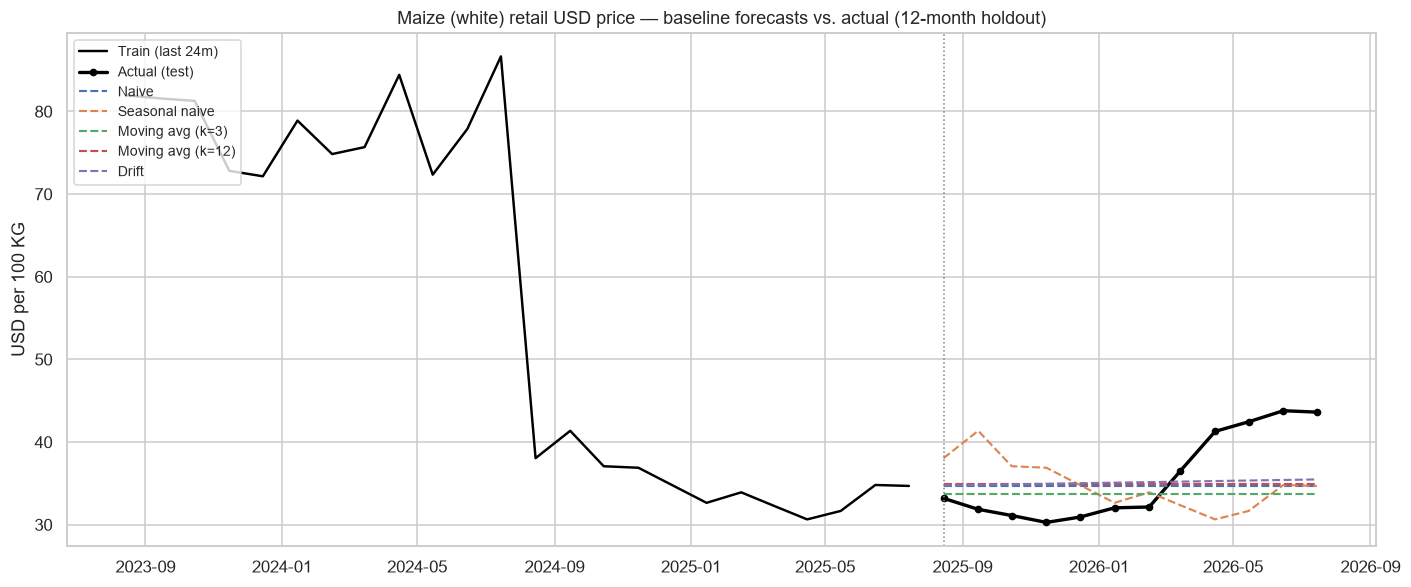

In [5]:
fig, ax = plt.subplots(figsize=(13, 5.5))
ax.plot(train.index[-24:], train.values[-24:], color='black', linewidth=1.6, label='Train (last 24m)')
ax.plot(test.index, test.values, color='black', linewidth=2.2, linestyle='-', marker='o', markersize=4, label='Actual (test)')

palette = sns.color_palette('deep', len(forecasts))
for (name, f), color in zip(forecasts.items(), palette):
    ax.plot(f.index, f.values, linestyle='--', linewidth=1.4, label=name, color=color)

ax.axvline(test.index[0], color='gray', linestyle=':', linewidth=1)
ax.set_title('Maize (white) retail USD price — baseline forecasts vs. actual (12-month holdout)')
ax.set_ylabel('USD per 100 KG')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()


The best-performing baseline is reported first in the sorted table above. In a strongly trending series
like this one, **drift** and **moving average** methods that account for trend generally out-perform a flat
naive forecast, while **seasonal naive** struggles because — as `05 TIME SERIES` found — the seasonal
component here is real but modest relative to the trend, so borrowing last year's absolute price level is a
weaker anchor than continuing the recent trend.


## 6.4 Residual diagnostics for the best baseline

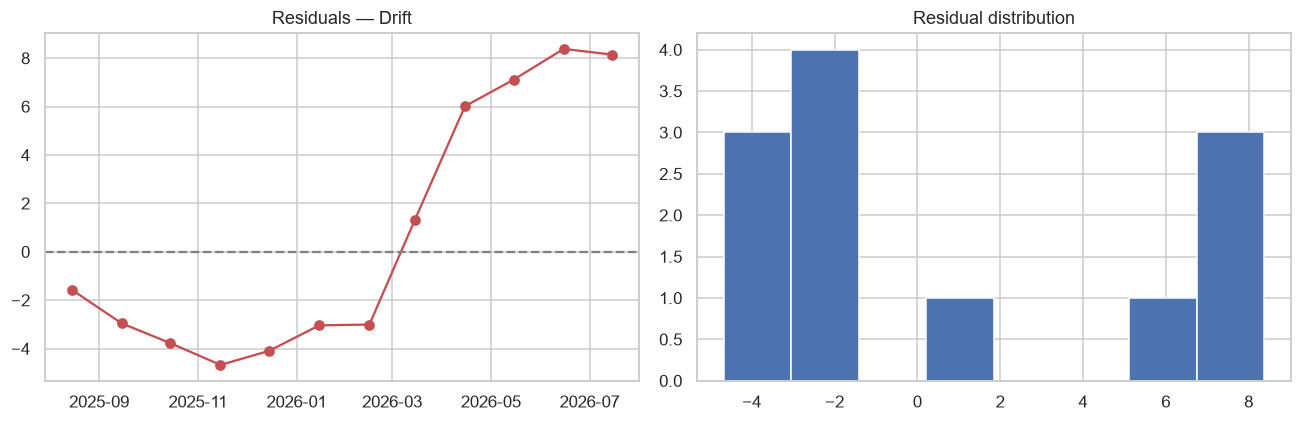

Best baseline: Drift
Mean residual: 0.651  (bias — positive means under-forecasting)


In [6]:
best_name = results_df.iloc[0]['Method']
best_forecast = forecasts[best_name]
residuals = test - best_forecast

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(residuals.index, residuals.values, marker='o', color='#C44E52')
axes[0].axhline(0, color='gray', linestyle='--')
axes[0].set_title(f'Residuals — {best_name}')

axes[1].hist(residuals.values, bins=8, color='#4C72B0', edgecolor='white')
axes[1].set_title('Residual distribution')

plt.tight_layout()
plt.show()

print(f'Best baseline: {best_name}')
print(f'Mean residual: {residuals.mean():.3f}  (bias — positive means under-forecasting)')


---
## Summary

- Held out the **last 12 months** as a test set for a fair, seasonally-complete evaluation.
- Implemented and compared five baselines: naive, seasonal naive, two moving averages, and drift.
- The trend-aware baselines (**drift**, **moving average**) beat the flat naive and seasonal-naive
  approaches on this series, consistent with `05 TIME SERIES` finding a trend-dominated, only mildly
  seasonal series.
- These baseline scores (MAE / RMSE / MAPE) are the bar that `07 ARIMA / SARIMA` and later ML models need
  to clear to justify their added complexity.
